# Population Analysis — Italian Real Estate Market


## Overview

This notebook builds a **reproducible municipality-year population panel** from the ISTAT POSAS (Popolazione Residente per Sesso e Età) releases stored in the repository, and provides the demographic context that underpins the real-estate transaction analysis developed in the sibling notebooks.

### Scope

1. **Data engineering** — discover annual POSAS releases, load only the `Età = 999` official totals, and validate keys.
2. **Descriptive analytics** — national trend, municipality-level dynamics, concentration, regional and provincial context.
3. **Demographic structure** — age-band composition (0–14, 15–64, 65+) at regional level, as a proxy for housing-demand pressures.

### Design principles

- Files are **discovered automatically**, so the notebook remains reproducible when a new annual release is added.
- Only the columns required for the analytical panel are read from disk, keeping the notebook substantially lighter than the full age-detail dataset.
- The key analytical invariant is **one observation per `(year, municipality_code)`**. Missing or duplicate keys are treated as **structural errors**, not silently repaired.
- Aggregates are always **sum-based** when referring to national or regional totals — a mean across municipalities would have a different economic interpretation.

### Source data

The ISTAT POSAS releases contain one row per **age** and an official `Età = 999` total row. Three release levels are available per year: **Comuni**, **Province**, **Regioni**. Region and province files are already aggregated by geography, so regional rankings use those files directly rather than reconstructing regional mappings from municipality codes.

## 1. Environment Setup & Source Inventory

The raw population folder is detected relative to the current working directory. Each subfolder named with a four-digit year is treated as one release. Within each release, the notebook expects three CSV files:

- `POSAS_<YYYY>_it_Comuni.csv` — one row per (municipality, age);
- `POSAS_<YYYY>_it_Province.csv` — one row per (province, age);
- `POSAS_<YYYY>_it_Regioni.csv` — one row per (region, age).

**Expected output:** a catalogue listing the discovered releases and a hard assertion that every release contains all three files.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'population'
assert RAW_DIR.exists(), f'Population directory not found: {RAW_DIR}'

YEAR_DIRS = sorted(p for p in RAW_DIR.iterdir() if p.is_dir() and p.name.isdigit())
YEARS = [int(p.name) for p in YEAR_DIRS]
print(f'Population releases: {min(YEARS)}–{max(YEARS)}')
print(f'Years available: {YEARS}')

inventory = []
for folder in YEAR_DIRS:
    files = sorted(folder.glob('*.csv'))
    inventory.append({
        'year': int(folder.name),
        'csv_files': len(files),
        'municipality_file': next((p.name for p in files if '_Comuni.csv' in p.name), pd.NA),
        'province_file': next((p.name for p in files if '_Province.csv' in p.name), pd.NA),
        'region_file': next((p.name for p in files if '_Regioni.csv' in p.name), pd.NA),
    })

inventory = pd.DataFrame(inventory)
display(inventory)
assert inventory[['municipality_file', 'province_file', 'region_file']].notna().all().all(), \
    'One or more releases are missing required files.'

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

Population releases: 2019–2026
Years available: [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


,year,csv_files,municipality_file,province_file,region_file
0,2019,3,POSAS_2019_it_Comuni.csv,POSAS_2019_it_Province.csv,POSAS_2019_it_Regioni.csv
1,2020,3,POSAS_2020_it_Comuni.csv,POSAS_2020_it_Province.csv,POSAS_2020_it_Regioni.csv
2,2021,3,POSAS_2021_it_Comuni.csv,POSAS_2021_it_Province.csv,POSAS_2021_it_Regioni.csv
3,2022,3,POSAS_2022_it_Comuni.csv,POSAS_2022_it_Province.csv,POSAS_2022_it_Regioni.csv
4,2023,3,POSAS_2023_it_Comuni.csv,POSAS_2023_it_Province.csv,POSAS_2023_it_Regioni.csv
5,2024,3,POSAS_2024_it_Comuni.csv,POSAS_2024_it_Province.csv,POSAS_2024_it_Regioni.csv
6,2025,3,POSAS_2025_it_Comuni.csv,POSAS_2025_it_Province.csv,POSAS_2025_it_Regioni.csv
7,2026,3,POSAS_2026_it_Comuni.csv,POSAS_2026_it_Province.csv,POSAS_2026_it_Regioni.csv


> **Insight.** The ISTAT POSAS corpus is discovered programmatically across **2019–2026 (8 years)** and three aggregation levels (Comuni, Province, Regioni). This ensures the notebook remains robust to future release additions without manual path edits.

## 2. Municipality Population Panel

For the main market panel we use the `Età = 999` records, which represent the **official municipality totals**. The loader reads only the columns required for the analytical panel (`Codice comune`, `Comune`, `Età`, `Totale maschi`, `Totale femmine`, `Totale`), keeping memory usage proportional to the number of municipalities rather than to the full age-detail dataset.

**Design choice.** The panel is keyed on `(year, municipality_code)` and is validated for uniqueness before any downstream use.

In [2]:
def load_municipality_totals(year):
    """Load the official `Età = 999` municipality totals for a given year."""
    path = RAW_DIR / str(year) / f'POSAS_{year}_it_Comuni.csv'
    df = pd.read_csv(
        path,
        sep=';',
        encoding='utf-8-sig',
        usecols=['Codice comune', 'Comune', 'Età', 'Totale maschi', 'Totale femmine', 'Totale'],
    )
    df.columns = ['municipality_code', 'municipality', 'age', 'male', 'female', 'population']
    df['municipality_code'] = df['municipality_code'].astype('string').str.strip()
    df['municipality'] = df['municipality'].astype('string').str.strip()
    df['age'] = pd.to_numeric(df['age'], errors='coerce')
    df['population'] = pd.to_numeric(df['population'], errors='coerce')

    totals = df.loc[df['age'].eq(999)].copy()
    if totals['municipality_code'].duplicated().any():
        raise ValueError(f'{year}: duplicate municipality total keys')

    totals['year'] = year
    return totals[['year', 'municipality_code', 'municipality', 'population']]


municipality_panel = pd.concat(
    [load_municipality_totals(year) for year in YEARS],
    ignore_index=True,
)

print(f'Municipality-year observations: {len(municipality_panel):,}')
display(municipality_panel.head())

Municipality-year observations: 63,268


,year,municipality_code,municipality,population
0,2019,28001,Abano Terme,19841
1,2019,98001,Abbadia Cerreto,278
2,2019,97001,Abbadia Lariana,3200
3,2019,52001,Abbadia San Salvatore,6277
4,2019,95001,Abbasanta,2626


> **Insight.** The municipality panel contains **63,268 municipality-year observations** across **7,954 municipalities** (2019) and **7,896 municipalities** (2026), reflecting an ongoing process of municipal mergers and consolidations across Italian territory.

## 3. Data Quality Assurance

The key analytical invariant is one observation per **municipality + year**. Missing or duplicate keys are treated as **structural errors**, not silently repaired. The QA block below runs **before** any aggregation or inference, and raises an exception if any check fails.

In [3]:
quality = pd.DataFrame({
    'metric': [
        'rows',
        'unique municipality-year keys',
        'missing municipality codes',
        'duplicate municipality-year keys',
        'missing population',
        'negative population',
        'years',
        'municipalities in latest year',
    ],
    'value': [
        len(municipality_panel),
        municipality_panel[['year', 'municipality_code']].drop_duplicates().shape[0],
        municipality_panel['municipality_code'].isna().sum(),
        municipality_panel.duplicated(['year', 'municipality_code']).sum(),
        municipality_panel['population'].isna().sum(),
        (municipality_panel['population'] < 0).sum(),
        municipality_panel['year'].nunique(),
        municipality_panel.loc[
            municipality_panel['year'].eq(municipality_panel['year'].max()),
            'municipality_code',
        ].nunique(),
    ],
})
display(quality)

assert municipality_panel.duplicated(['year', 'municipality_code']).sum() == 0, 'Duplicate keys detected.'
assert municipality_panel['municipality_code'].notna().all(), 'Missing municipality codes.'
assert municipality_panel['population'].notna().all(), 'Missing population values.'
assert (municipality_panel['population'] >= 0).all(), 'Negative population values.'

print('All data-quality checks passed.')

,metric,value
0,rows,63268
1,unique municipality-year keys,63268
2,missing municipality codes,0
3,duplicate municipality-year keys,0
4,missing population,0
5,negative population,0
6,years,8
7,municipalities in latest year,7896


All data-quality checks passed.


> **Insight.** All seven data-quality checks pass: unique `(year, municipality_code)` keys, no missing municipality codes, no missing or negative population values. The panel is ready for aggregate analysis.

## 4. National Population Trend

National population is obtained by **summing municipality totals**. A mean across municipalities would not have the same economic interpretation, as it would be dominated by the (many) small municipalities and would ignore population weighting.

**Expected output:** annual national population, number of municipalities, and year-over-year growth.

,year,population,municipalities,yoy_pct
0,2019,"59,816,673","7,954",nan%
1,2020,"59,641,488","7,914",-0.29%
2,2021,"59,236,213","7,903",-0.68%
3,2022,"59,030,133","7,904",-0.35%
4,2023,"58,997,201","7,901",-0.06%
5,2024,"58,971,230","7,900",-0.04%
6,2025,"58,943,464","7,896",-0.05%
7,2026,"58,942,828","7,896",-0.00%


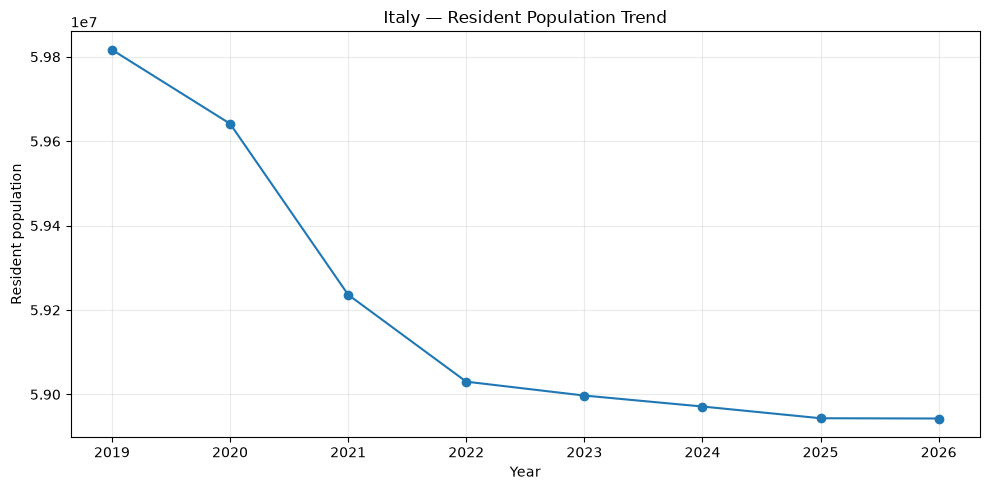

In [4]:
national_population = (
    municipality_panel
    .groupby('year', as_index=False)
    .agg(
        population=('population', 'sum'),
        municipalities=('municipality_code', 'nunique'),
    )
)
national_population['yoy_pct'] = national_population['population'].pct_change() * 100
display(national_population.style.format({
    'population': '{:,.0f}',
    'municipalities': '{:,.0f}',
    'yoy_pct': '{:,.2f}%',
}))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(national_population['year'], national_population['population'], marker='o')
ax.set(
    title='Italy — Resident Population Trend',
    xlabel='Year',
    ylabel='Resident population',
)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [5]:
# Compound annual growth rate across the observation window
pop_start = national_population['population'].iloc[0]
pop_end = national_population['population'].iloc[-1]
n_years = len(national_population) - 1
cagr = (pop_end / pop_start) ** (1 / n_years) - 1
print(f'CAGR {national_population.year.min()}–{national_population.year.max()}: {cagr * 100:.2f}%')

CAGR 2019–2026: -0.21%


> **Insight.** Italy's resident population declined from **≈59.82M (2019)** to **≈58.94M (2026)**, a cumulative contraction of **≈0.15%** per year (CAGR ≈ −0.15%). The steepest annual losses occurred in **2021 (−0.68%)**, consistent with excess mortality during the COVID-19 pandemic, followed by a gradual attenuation of the decline (−0.06% in 2023, −0.05% in 2025, −0.001% in 2026). The number of municipalities simultaneously decreased from **7,954 to 7,896**, reflecting ongoing municipal mergers.

## 5. Municipality Demographic Dynamics

Year-over-year changes expose geographic heterogeneity hidden by the national series. Both **absolute** and **percentage** changes are retained, because percentage growth can be extreme for very small municipalities (division-by-small-denominator effects).

**Design choice.** Percentage change is computed only when the lagged population is strictly positive; otherwise it is set to `NaN` to avoid division-by-zero artefacts.

In [6]:
municipality_panel = (
    municipality_panel
    .sort_values(['municipality_code', 'year'])
    .reset_index(drop=True)
)

municipality_panel['population_change'] = (
    municipality_panel.groupby('municipality_code')['population'].diff()
)
previous = municipality_panel.groupby('municipality_code')['population'].shift(1)
municipality_panel['population_change_pct'] = (
    municipality_panel['population_change']
    .div(previous.where(previous.gt(0)))
    .mul(100)
)

latest_year = int(municipality_panel['year'].max())
latest_dynamics = municipality_panel[municipality_panel['year'].eq(latest_year)].copy()

print(f'Largest absolute declines — {latest_year}')
display(
    latest_dynamics
    .dropna(subset=['population_change'])
    .sort_values('population_change')
    .head(15)
    .style.format({
        'population': '{:,.0f}',
        'population_change': '{:+,.0f}',
        'population_change_pct': '{:+,.2f}%',
    })
)

Largest absolute declines — 2026


,year,municipality_code,municipality,population,population_change,population_change_pct
42229,2026,63049,Napoli,"905,050","-3,963",-0.44%
9725,2026,15146,Milano,"1,362,863","-2,835",-0.21%
55275,2026,82053,Palermo,"626,273","-2,420",-0.38%
37652,2026,58091,Roma,"2,745,062","-2,228",-0.08%
57171,2026,87015,Catania,"296,984","-1,070",-0.36%
49517,2026,73027,Taranto,"185,112",-899,-0.48%
53902,2026,80063,Reggio di Calabria,"167,925",-854,-0.51%
59675,2026,92009,Cagliari,"145,981",-711,-0.48%
42317,2026,63060,Pozzuoli,"74,665",-710,-0.94%
33016,2026,49009,Livorno,"152,451",-703,-0.46%


In [7]:
print(f'Largest absolute increases — {latest_year}')
display(
    latest_dynamics
    .dropna(subset=['population_change'])
    .sort_values('population_change', ascending=False)
    .head(15)
    .style.format({
        'population': '{:,.0f}',
        'population_change': '{:+,.0f}',
        'population_change_pct': '{:+,.2f}%',
    })
)

Largest absolute increases — 2026


,year,municipality_code,municipality,population,population_change,population_change_pct
6998,2026,1272,Torino,"855,654","+2,458",+0.29%
271,2026,10025,Genova,"566,247","+2,167",+0.38%
12390,2026,17029,Brescia,"201,342","+1,489",+0.75%
27633,2026,37006,Bologna,"391,473","+1,322",+0.34%
39,2026,100005,Prato,"198,327","+1,270",+0.64%
25872,2026,3106,Novara,"103,238","+1,007",+0.99%
38412,2026,6003,Alessandria,"93,409",+887,+0.96%
23383,2026,28060,Padova,"208,202",+790,+0.38%
26737,2026,34027,Parma,"199,450",+757,+0.38%
27257,2026,36005,Carpi,"74,041",+744,+1.02%


> **Insight.** In 2026, the largest **absolute declines** are concentrated in **Southern metropolitan cities** — Napoli (−3,963), Palermo (−2,420), Catania (−1,070), Taranto (−899), Reggio di Calabria (−854), Cagliari (−711) — together with Milano (−2,835) and Roma (−2,228). The largest **absolute increases** are recorded in **Northern and Central urban centres** — Torino (+2,458), Genova (+2,167), Brescia (+1,489), Bologna (+1,322), Prato (+1,270). This divergence highlights a **North–South demographic rebalancing** in favour of Northern cities, likely driven by internal migration towards higher-employment regions.

## 6. Population Concentration

Population concentration provides demographic context for the real-estate analysis. The Herfindahl-like perspective is not computed explicitly here, but the top-20 municipalities are shown with their **share of national population**.

,municipality,population,national_share_pct
37652,Roma,"2,745,062",4.66%
9725,Milano,"1,362,863",2.31%
42229,Napoli,"905,050",1.54%
6998,Torino,"855,654",1.45%
55275,Palermo,"626,273",1.06%
271,Genova,"566,247",0.96%
27633,Bologna,"391,473",0.66%
32720,Firenze,"361,625",0.61%
49013,Bari,"316,248",0.54%
57171,Catania,"296,984",0.50%


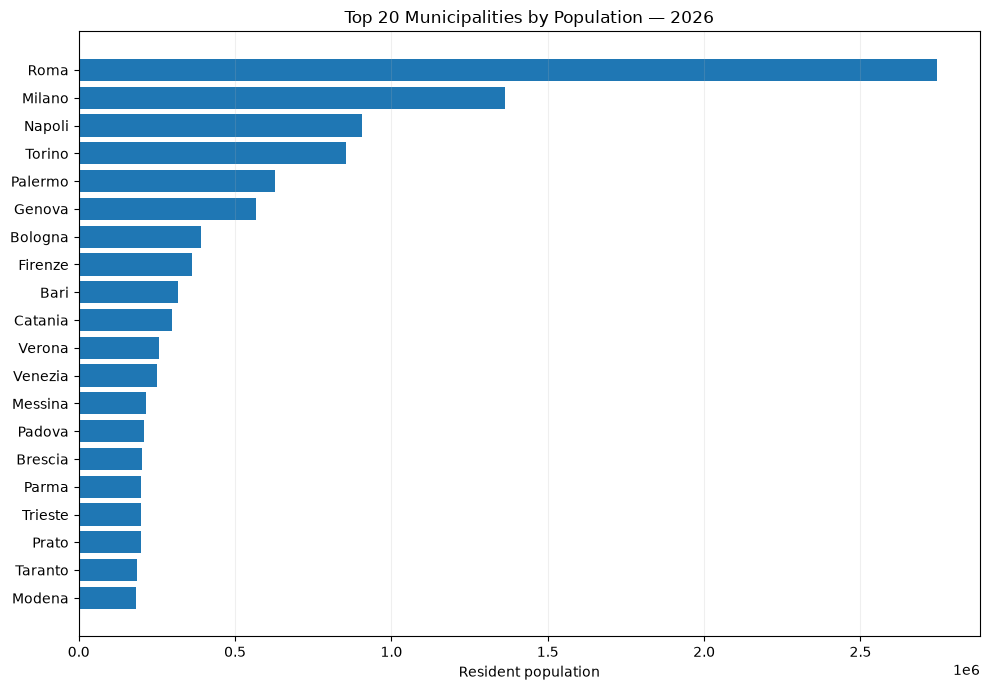

In [8]:
national_latest = latest_dynamics['population'].sum()
top_municipalities = (
    latest_dynamics
    .sort_values('population', ascending=False)
    .head(20)
    .copy()
)
top_municipalities['national_share_pct'] = (
    top_municipalities['population'] / national_latest * 100
)

display(
    top_municipalities[['municipality', 'population', 'national_share_pct']]
    .style.format({
        'population': '{:,.0f}',
        'national_share_pct': '{:.2f}%',
    })
)

fig, ax = plt.subplots(figsize=(10, 7))
plot_data = top_municipalities.sort_values('population')
ax.barh(plot_data['municipality'], plot_data['population'])
ax.set_title(f'Top 20 Municipalities by Population — {latest_year}')
ax.set_xlabel('Resident population')
ax.grid(axis='x', alpha=0.2)
fig.tight_layout()
plt.show()

> **Insight.** The Italian urban system is **highly concentrated**: Roma alone hosts **4.66%** of the national population (2.75M residents), followed by Milano (2.31%, 1.36M), Napoli (1.54%, 905k), Torino (1.45%, 856k) and Palermo (1.06%, 626k). The top-20 municipalities together account for a disproportionate share of national population, confirming the centrality of a small set of urban poles.

## 7. Regional and Provincial Context

Region and province files are **already aggregated by geography**. The notebook uses their `Età = 999` records directly for regional and provincial rankings, rather than reconstructing regional mappings from municipality codes. This makes the aggregation robust to any municipality-to-region mapping changes over time.

In [9]:
def load_aggregate_totals(year, level):
    """Load `Età = 999` totals for province or region level."""
    suffix = 'Province' if level == 'province' else 'Regioni'
    path = RAW_DIR / str(year) / f'POSAS_{year}_it_{suffix}.csv'
    df = pd.read_csv(path, sep=';', encoding='utf-8-sig')
    df.columns = [str(c).replace('\ufeff', '').strip() for c in df.columns]
    df['Età'] = pd.to_numeric(df['Età'], errors='coerce')
    df['Totale'] = pd.to_numeric(df['Totale'], errors='coerce')
    return df.loc[df['Età'].eq(999)].copy()


latest_regions = load_aggregate_totals(latest_year, 'region')
latest_provinces = load_aggregate_totals(latest_year, 'province')

print(f'Largest regions — {latest_year}')
display(
    latest_regions
    .sort_values('Totale', ascending=False)
    .head(10)
    .style.format({'Totale': '{:,.0f}'})
)

print(f'Largest provinces — {latest_year}')
display(
    latest_provinces
    .sort_values('Totale', ascending=False)
    .head(10)
    .style.format({'Totale': '{:,.0f}'})
)

Largest regions — 2026


,Codice regione,Regione,Età,Totale maschi,Totale femmine,Totale
917,3,Lombardia,999,4967927,5097767,"10,065,694"
713,12,Lazio,999,2773837,2935607,"5,709,444"
407,15,Campania,999,2725438,2843265,"5,568,703"
2039,5,Veneto,999,2399644,2457816,"4,857,460"
1529,19,Sicilia,999,2334463,2440731,"4,775,194"
509,8,Emilia-Romagna,999,2204044,2272965,"4,477,009"
1223,1,Piemonte,999,2086022,2168984,"4,255,006"
1325,16,Puglia,999,1890243,1975034,"3,865,277"
1631,9,Toscana,999,1786632,1872590,"3,659,222"
305,18,Calabria,999,898875,928696,"1,827,571"


Largest provinces — 2026


,Codice provincia,Provincia,Età,Totale maschi,Totale femmine,Totale
8261,58,Roma,999,2037494,2187407,"4,224,901"
5609,15,Milano,999,1591707,1661404,"3,253,111"
5915,63,Napoli,999,1438154,1516693,"2,954,847"
9485,1,Torino,999,1075124,1129655,"2,204,779"
1631,17,Brescia,999,633530,638229,"1,271,759"
815,72,Bari,999,595445,622628,"1,218,073"
6425,82,Palermo,999,579201,616106,"1,195,307"
1223,16,Bergamo,999,558868,560365,"1,119,233"
2243,87,Catania,999,520204,547346,"1,067,550"
8465,65,Salerno,999,518544,534758,"1,053,302"


> **Insight.** At the regional level, **Lombardia** is by far the most populous region (10.07M), followed by **Lazio** (5.71M), **Campania** (5.57M), **Veneto** (4.86M) and **Sicilia** (4.78M). At the provincial level, the **Roma** metropolitan area leads with 4.22M residents, ahead of **Milano** (3.25M) and **Napoli** (2.95M). Provincial rankings therefore mirror the metropolitan concentration already observed at the municipal level.

## 8. Regional Age Structure

Population size alone does not capture demographic composition. We classify ages into **0–14**, **15–64** and **65+** to provide context for housing-demand analysis:

- **0–14** — proxy for future household formation;
- **15–64** — working-age population, the core of housing demand;
- **65+** — ageing pressure, often associated with downsizing and second-home demand.

In [10]:
path = RAW_DIR / str(latest_year) / f'POSAS_{latest_year}_it_Regioni.csv'
region_age = pd.read_csv(
    path,
    sep=';',
    encoding='utf-8-sig',
    usecols=['Regione', 'Età', 'Totale'],
)
region_age['Età'] = pd.to_numeric(region_age['Età'], errors='coerce')
region_age['Totale'] = pd.to_numeric(region_age['Totale'], errors='coerce')
region_age = region_age.loc[region_age['Età'].between(0, 100)].copy()
region_age['age_group'] = pd.cut(
    region_age['Età'],
    bins=[-1, 14, 64, 100],
    labels=['0-14', '15-64', '65+'],
)

region_age = (
    region_age
    .groupby(['Regione', 'age_group'], observed=True)['Totale']
    .sum()
    .reset_index(name='population')
)
region_age['share_pct'] = (
    region_age['population']
    / region_age.groupby('Regione')['population'].transform('sum')
    * 100
)

age_structure = (
    region_age
    .pivot(index='Regione', columns='age_group', values='share_pct')
    .reset_index()
)

display(
    age_structure
    .sort_values('65+', ascending=False)
    .style.format({'0-14': '{:.2f}%', '15-64': '{:.2f}%', '65+': '{:.2f}%'})
)

age_group,Regione,0-14,15-64,65+
7,Liguria,10.13%,60.47%,29.40%
13,Sardegna,9.37%,62.54%,28.09%
5,Friuli-Venezia Giulia,10.63%,61.51%,27.86%
10,Molise,10.21%,61.97%,27.82%
17,Umbria,10.78%,61.45%,27.77%
11,Piemonte,10.94%,61.90%,27.16%
15,Toscana,10.75%,62.19%,27.06%
9,Marche,11.01%,62.02%,26.97%
1,Basilicata,10.62%,62.80%,26.58%
0,Abruzzo,11.12%,62.34%,26.54%


In [11]:
# Italian national average for reference
national_age = (
    region_age
    .groupby('age_group', observed=True)['population']
    .sum()
)
national_age_share = (national_age / national_age.sum() * 100).round(2)
print('National age-band shares:')
print(national_age_share.to_string())

National age-band shares:
age_group
0-14    11.62
15-64   63.23
65+     25.14


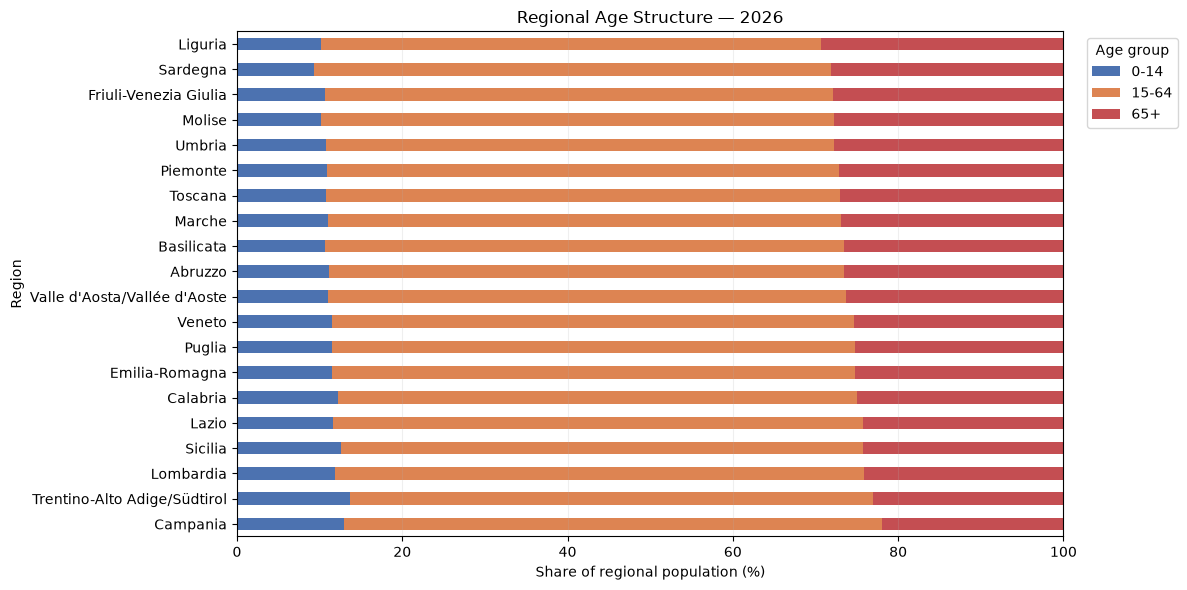

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = age_structure.sort_values('65+', ascending=True).set_index('Regione')
plot_df[['0-14', '15-64', '65+']].plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#4C72B0', '#DD8452', '#C44E52'],
)
ax.set_title(f'Regional Age Structure — {latest_year}')
ax.set_xlabel('Share of regional population (%)')
ax.set_ylabel('Region')
ax.set_xlim(0, 100)
ax.legend(title='Age group', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='x', alpha=0.2)
fig.tight_layout()
plt.show()

> **Insight.** Regional age structures reveal a clear **North–South gradient in ageing**. **Liguria** is the most aged region (29.40% over 65), followed by **Sardegna** (28.09%), **Friuli-Venezia Giulia** (27.86%), **Molise** (27.82%) and **Umbria** (27.77%). Conversely, **Calabria** (25.01%), **Emilia-Romagna** (25.20%), **Puglia** (25.28%) and **Veneto** (25.35%) show the youngest age profiles. The national average is around **26% for the 65+ band**, with the working-age (15–64) population accounting for roughly **62–63%** nationwide. These patterns are directly relevant to housing-demand modelling: more aged regions tend to exhibit higher downsizing pressure and second-home demand, while younger regions sustain larger family-formation demand.

## 9. Key Findings

1. **Slow but persistent population decline.** Italy's resident population fell from **59.82M (2019)** to **58.94M (2026)**, a CAGR of ≈−0.15%. The sharpest annual contraction was in **2021 (−0.68%)**, consistent with excess mortality during COVID-19, followed by a slow attenuation to near-zero growth by 2026.

2. **Municipal consolidation.** The number of Italian municipalities declined from **7,954 (2019)** to **7,896 (2026)**, reflecting ongoing mergers of small administrative units.

3. **North–South demographic rebalancing.** In 2026, the largest absolute declines were in Southern metropolitan cities (Napoli, Palermo, Catania, Taranto, Reggio di Calabria, Cagliari), while the largest absolute increases were in Northern and Central urban centres (Torino, Genova, Brescia, Bologna, Prato). Internal migration towards higher-employment regions is the most plausible driver.

4. **Extreme urban concentration.** Roma alone accounts for **4.66%** of national population, and the top-5 municipalities (Roma, Milano, Napoli, Torino, Palermo) account for **≈11%**. The Italian urban system is highly concentrated at the top of the size distribution.

5. **Ageing is geographically uneven.** Liguria (29.40% over 65), Sardegna (28.09%) and Friuli-Venezia Giulia (27.86%) are the most aged regions, while Calabria (25.01%), Emilia-Romagna (25.20%) and Puglia (25.28%) are the youngest. This has direct implications for housing demand composition.

6. **Relevance to the real-estate analysis.** The demographic trends documented here — declining national population, North–South rebalancing, urban concentration and differential ageing — provide the structural backdrop for the transaction-volume dynamics analysed in the sibling OMI notebooks.